# 🌡️ Sıcaklık (Temperature) ve Otoregresif Metin Üretimi

Bu notebook'ta dil modellerinin metin üretirken nasıl karar verdiğini öğreneceğiz:

- **Sıcaklık (Temperature)**: Modelin ne kadar "tutucu" ya da "yaratıcı" davranacağını kontrol eden parametre
- **Otoregresyon**: Her adımda bir kelime tahmin edip, onu girdi olarak kullanarak sonraki kelimeyi tahmin etme süreci
- **Örnekleme Stratejileri**: Greedy, Temperature Sampling, Top-k, Top-p — modelin çıktı seçerken hangi kuralları izlediği

Son olarak bunları **bigram modeli** (her kelimeden sonra hangi kelime geldiği) üzerinde uygulaıp metin üretim demosunu göreceğiz.

<a href="https://colab.research.google.com/github/sevval-345/NLP/blob/main/s%C4%B1cakl%C4%B1k_ve__otoregresyon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import re                        # metni temizlemek ve kelimelere ayırmak için düzenli ifadeler
import numpy as np                # softmax, olasılık vektörleri ve rastgele örnekleme için
import matplotlib.pyplot as plt   # olasılık dağılımlarını çubuk grafikle çizmek için

# Tekrar üretilebilirlik için sabit tohum: aynı kodu tekrar çalıştırınca
# rastgele sayılar (örnekleme adımlarında) hep aynı çıksın, sonuçlar şansa bağlı görünmesin.
rng_global = np.random.default_rng(42)

# Grafiklerin görünümünü sadeleştiren ayarlar (üst ve sağ çizgileri kaldırır, çözünürlüğü artırır)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Adım 1: Kütüphaneler ve Ayarlar

Aşağıda kullanacağımız kütüphaneleri yükleyeceğiz:
- **numpy**: Matematiksel işlemler (softmax, olasılık hesaplamaları)
- **matplotlib**: Grafik çizimi
- İşlemleri tekrar edilebilir yapmak için **sabit tohum (seed)** belirleceğiz — bu sayede kodu her çalıştırdığında aynı rastgele sayılar üretilir.

In [8]:

def softmax_with_temperature(logits, T=1.0):
    """Logit vektörünü, T sıcaklığıyla ölçekleyip olasılık dağılımına çevirir."""
    logits = np.asarray(logits, dtype=float) / T   # 1. adım: her logiti T'ye böl (sıcaklık ölçekleme)
    logits = logits - logits.max()                 # 2. adım: en büyük değeri çıkar (sayısal kararlılık, e^büyük_sayı taşmasını engeller)
    exp_logits = np.exp(logits)                     # 3. adım: her ölçeklenmiş logitin e tabanındaki üssünü al
    return exp_logits / exp_logits.sum()             # 4. adım: toplama böl -> toplamı 1 olan bir olasılık dağılımı elde et


# Örnek: modelin 5 kelime için ürettiği varsayımsal ham logitler
kelimeler = ["kedi", "araba", "ev", "et", "fil"]
logits = [2.0, 1.5, 0.5, 0.3, 1.0]   # logitler keyfi sayılardır, henüz olasılık değildir (negatif de olabilir, toplamları 1 değildir)

# Başlık satırını yazdır: sütun başına bir kelime adı
print(f"{'Sıcaklık':<10}" + "".join(f"{k:>10}" for k in kelimeler))

# Aynı logitleri farklı sıcaklıklarla deneyip her satırda bir T değerinin sonucunu yazdır
for T in [0.2, 0.5, 1.0, 1.5, 3.0]:
    probs = softmax_with_temperature(logits, T)               # bu T için olasılık dağılımını hesapla
    print(f"T={T:<8}" + "".join(f"{p:>10.1%}" for p in probs))  # yüzde formatında satır satır yazdır


Sıcaklık        kedi     araba        ev        et       fil
T=0.2          91.8%      7.5%      0.1%      0.0%      0.6%
T=0.5          63.0%     23.2%      3.1%      2.1%      8.5%
T=1.0          42.0%     25.5%      9.4%      7.7%     15.5%
T=1.5          34.2%     24.5%     12.6%     11.0%     17.6%
T=3.0          26.8%     22.7%     16.2%     15.2%     19.2%


## Adım 2: Sıcaklık ve Softmax

**Sıcaklık nedir?**

Dil modeli, her kelime için bir "logit" (iç puanı) hesaplar. Bu puanlar negatif de olabilir, toplamları 1 değildir — henüz olasılık değildir.

**Softmax**, bu logitleri olasılık dağılımına çevirme işlemini yapar (tümü 0 ile 1 arasında, toplamları 1).

**Sıcaklık (T)** ise, bu dağılımın ne kadar "sert" ya da "yumuşak" olacağını kontrol eder:
- **T → 0** (düşük sıcaklık): Dağılım keskinleşir, en yüksek olasılık çok daha baskın hale gelir → tutucu çıktı
- **T = 1** (normal): Standart softmax — dengeli dağılım
- **T → ∞** (yüksek sıcaklık): Dağılım düzleşir, tüm seçenekler daha eşit şansa sahip olur → yaratıcı/riskli çıktı

Aşağıda her sıcaklık seviyesinin dağılımı nasıl değiştirdiğini göreceğiz:

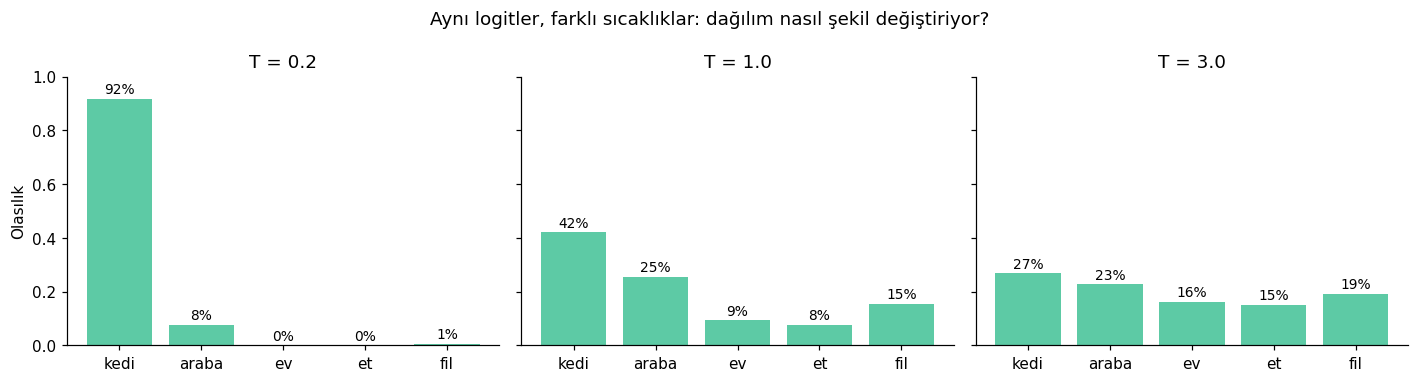

In [9]:

temperatures = [0.2, 1.0, 3.0]                                       # karşılaştırılacak üç sıcaklık değeri
fig, axes = plt.subplots(1, len(temperatures), figsize=(13, 3.5), sharey=True)  # yan yana 3 grafik alanı oluştur, y eksenini paylaştır

for ax, T in zip(axes, temperatures):
    probs = softmax_with_temperature(logits, T)                       # bu sıcaklık için olasılıkları hesapla
    bars = ax.bar(kelimeler, probs, color="#5DCAA5")                    # her kelime için bir çubuk çiz
    ax.set_title(f"T = {T}")
    ax.set_ylim(0, 1)                                                   # y eksenini 0-1 (yüzde 0-100) aralığında sabitle
    for bar, p in zip(bars, probs):
        ax.text(bar.get_x() + bar.get_width() / 2, p + 0.02, f"{p:.0%}",  # çubuğun üstüne yüzde değerini yaz
                 ha="center", fontsize=9)

axes[0].set_ylabel("Olasılık")
fig.suptitle("Aynı logitler, farklı sıcaklıklar: dağılım nasıl şekil değiştiriyor?")
plt.tight_layout()
plt.show()


### Görsel Demo: Sıcaklık Dağılım Değiştiriyor

Aşağıdaki grafiklerde **aynı logitler** (model puanları) kullanılıyor, ama farklı sıcaklıklarla softmax uygulanıyor. Gördüğünüz üzere:
- Sol grafik (T=0.2): En olası kelime baskın, diğerleri neredeyse hiç seçilmez
- Orta grafik (T=1.0): Dengeli dağılım
- Sağ grafik (T=3.0): Tüm kelimeler daha eşit şansa sahip, daha rastgele

In [10]:

def greedy_index(probs):
    # En yüksek olasılığa sahip elemanın indeksini döndürür -> her zaman aynı seçim, rastgelelik yok
    return int(np.argmax(probs))


def temperature_sample_index(probs, rng):
    # probs dizisini ağırlık olarak kullanarak rastgele bir indeks çeker (zar atmak gibi)
    return int(rng.choice(len(probs), p=probs))


def top_k_index(probs, k, rng):
    k = min(k, len(probs))                      # k, eleman sayısından büyük olamaz
    top_idx = np.argsort(probs)[-k:]            # en yüksek k olasılığın indeksleri (küçükten büyüğe sıralayıp son k'yı al)
    top_probs = probs[top_idx]
    top_probs = top_probs / top_probs.sum()      # havuzu yeniden normalize et (toplamları yine 1 olsun)
    return int(rng.choice(top_idx, p=top_probs))  # sadece bu k'lık havuzdan örnekle


def top_p_index(probs, p, rng):
    order = np.argsort(probs)[::-1]              # büyükten küçüğe sırala
    sorted_probs = probs[order]
    cumulative = np.cumsum(sorted_probs)          # kümülatif (biriken) olasılık toplamı
    cutoff = int(np.searchsorted(cumulative, p)) + 1  # kümülatif toplam p'yi geçtiği ilk noktayı bul
    pool_idx = order[:cutoff]                     # havuz: kümülatif olasılığı p'ye getiren en olası kelimeler
    pool_probs = probs[pool_idx]
    pool_probs = pool_probs / pool_probs.sum()     # havuzu yeniden normalize et
    return int(rng.choice(pool_idx, p=pool_probs))  # sadece bu (değişken boyutlu) havuzdan örnekle


# Aynı dağılım üzerinde dört stratejiyi karşılaştıralım
probs_demo = softmax_with_temperature(logits, T=1.0)  # T=1.0: ölçeklenmemiş "ham" dağılım
rng = np.random.default_rng(7)                          # bu hücreye özel, sabit bir rastgelelik kaynağı

print("Dağılım:", dict(zip(kelimeler, np.round(probs_demo, 3))))
print("Greedy        ->", kelimeler[greedy_index(probs_demo)])
print("Temperature   ->", kelimeler[temperature_sample_index(probs_demo, rng)])
print("Top-k (k=2)   ->", kelimeler[top_k_index(probs_demo, 2, rng)])
print("Top-p (p=0.8) ->", kelimeler[top_p_index(probs_demo, 0.8, rng)])


Dağılım: {'kedi': np.float64(0.42), 'araba': np.float64(0.255), 'ev': np.float64(0.094), 'et': np.float64(0.077), 'fil': np.float64(0.155)}
Greedy        -> kedi
Temperature   -> araba
Top-k (k=2)   -> kedi
Top-p (p=0.8) -> araba


## Adım 3: Örnekleme Stratejileri

Olasılık dağılımından kelime seçmek için farklı yöntemler vardır:

| Strateji | Açıklama | Kullanım |
|----------|----------|---------|
| **Greedy** | Her zaman en yüksek olasılığa sahip kelimeyi seç | Determinist, tekrarlanan çıktılar |
| **Temperature Sampling** | Dağılımın tamamından rastgele seç (sıcaklığa göre ayarla) | Yaratıcı, doğal metin |
| **Top-k** | En olası k kelime arasından seç | İyi seçeneklerle rastgelelik |
| **Top-p (Nucleus)** | Kümülatif olasılığı p'ye getiren kelimeleri seç | Esnek dinamik havuz |

Aşağıdaki kod her stratejinin tanımını ve örneğini gösterir:

In [11]:

corpus = """
Bugün hava çok güzeldi. Bugün hava biraz bulutluydu. Bugün hava aniden bozdu.
Güneş erkenden doğdu ve ortalığı aydınlattı. Güneş öğleden sonra kayboldu ve
hava kararttı. Çocuklar parkta oynadı ve güldü. Çocuklar parkta koştu ve
yoruldu. Çocuklar bahçede saklambaç oynadı. Köpekler bahçede koştu ve havladı.
Köpekler bahçede uyukladı. Akşam olunca rüzgar şiddetlendi ve yapraklar
uçuştu. Akşam olunca gökyüzü kızıla döndü. Akşam olunca herkes evine çekildi.
Yağmur birden başladı ve sokakları ıslattı. Yağmur kısa sürdü ve hemen durdu.
Yağmur uzun sürdü ve göletler oluştu. Yağmur birden bastırdı ve herkes kaçıştı.
İnsanlar şemsiyelerini açtı ve yürüdü.
İnsanlar pencereden dışarı baktı. Gece olunca gökyüzü yıldızlarla doldu.
Gece olunca ay parlak bir şekilde belirdi. Gece olunca sessizlik çöktü.
Herkes evine huzur içinde döndü. Herkes mutlu bir şekilde uyudu. Bugün hava
çok değişkendi ama güzel bir gündü.
"""


def tokenize(text):
    text = text.replace("İ", "i").replace("I", "ı")  # Türkçe büyük/küçük harf tuzağı: Python'ın varsayılan .lower() "İ"yi yanlış çevirir
    text = text.lower()                                # tüm metni küçük harfe çevir (aksi halde "Hava" ve "hava" farklı kelime sayılır)
    text = re.sub(r"[^\w\sçğıöşüâî]", " ", text, flags=re.UNICODE)  # noktalama işaretlerini boşlukla değiştir, Türkçe harfleri koru
    return text.split()                                  # boşluklardan böl -> kelime listesi döndür


tokens = tokenize(corpus)
print(f"Toplam token sayısı: {len(tokens)}")
print(f"Benzersiz kelime sayısı: {len(set(tokens))}")
print("İlk 15 token:", tokens[:15])


Toplam token sayısı: 131
Benzersiz kelime sayısı: 80
İlk 15 token: ['bugün', 'hava', 'çok', 'güzeldi', 'bugün', 'hava', 'biraz', 'bulutluydu', 'bugün', 'hava', 'aniden', 'bozdu', 'güneş', 'erkenden', 'doğdu']


## Adım 4: Bigram Modeli — Veriyi Hazırla

Artık gerçekçi bir örnekle çalışacağız. Bir **bigram modeli** oluşturacağız:
- Bu model, her kelimeden **sonra hangi kelimelerin geldiğini** sayar
- Örneğin: "Bugün hava çok güzeldi. Bugün hava biraz bulutluydu." metininde "Bugün"den sonra 2 kez "hava", "hava"dan sonra "çok" ve "biraz" gelir
- Daha sonra bu sayımları, metin üretmek için olasılık dağılımına çevireceğiz

Önce metni tokenize edelim (temizle ve kelimelere böl):

In [12]:

# Bigram sayım tablosu: bigram_counts["hava"] = {"çok": 2, "birden": 1, ...}
bigram_counts = {}
# zip(tokens[:-1], tokens[1:]) -> her kelimeyi kendinden sonraki kelimeyle eşler:
# [bugün, hava, çok, ...] üzerinde (bugün, hava), (hava, çok), ... çiftlerini gezer
for current_word, next_word in zip(tokens[:-1], tokens[1:]):
    bigram_counts.setdefault(current_word, {})                                   # bu kelime ilk kez görülüyorsa boş bir sözlük aç
    bigram_counts[current_word][next_word] = bigram_counts[current_word].get(next_word, 0) + 1  # sayacı bir artır

# "hava" kelimesinden sonra hangi kelimeler hangi sıklıkla geliyor?
print("'hava' kelimesinden sonra gözlenen kelimeler:")
for kelime, sayi in bigram_counts["hava"].items():
    print(f"  {kelime!r:<12} -> {sayi} kez")


'hava' kelimesinden sonra gözlenen kelimeler:
  'çok'        -> 2 kez
  'biraz'      -> 1 kez
  'aniden'     -> 1 kez
  'kararttı'   -> 1 kez


### Bigram Sayımı Tablosu Oluştur

Şimdi bigram tablosunu yapacağız:
- **bigram_counts["hava"]** = `{"çok": 2, "birden": 1, ...}` — "hava" kelimesinden sonra "çok" 2 kez, "birden" 1 kez geldi
- Bu sayımları **olasılıklara çevireceğiz** (Örn: P(çok|hava) = 2/3 ≈ 0.67)

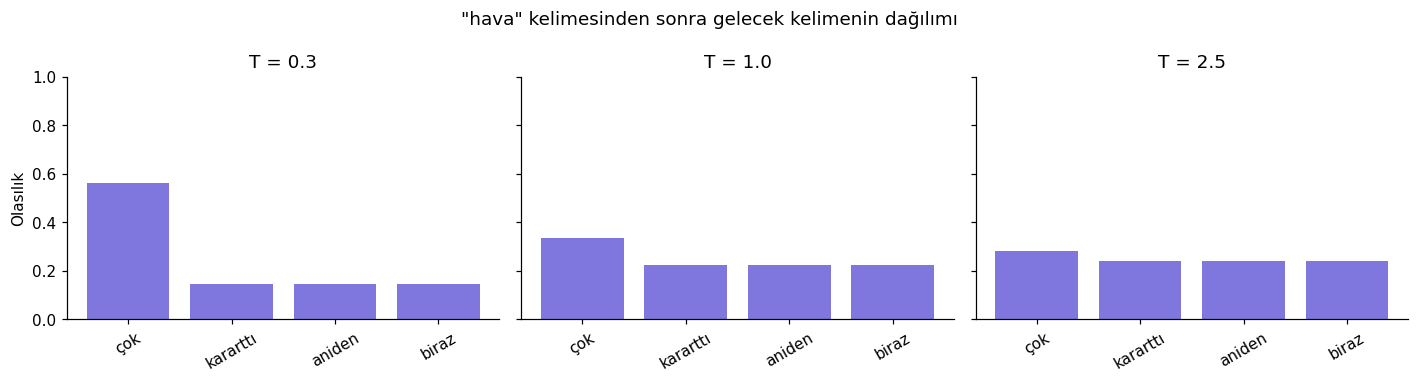

In [13]:

def predict_next_word(current_word, temperature=1.0):
    """current_word'den sonra gelebilecek kelimelerin (kelime_listesi, olasılık_dizisi) çiftini döndürür.
    current_word hiç görülmemişse None döner (zincir kopar)."""
    if current_word not in bigram_counts:
        return None                                                  # bu kelimeden sonrası hiç gözlenmedi -> tahmin yapılamaz
    candidates = list(bigram_counts[current_word].keys())              # bu kelimeden sonra gözlenen tüm farklı kelimeler
    counts = np.array([bigram_counts[current_word][c] for c in candidates], dtype=float)  # her birinin kaç kez gözlendiği
    pseudo_logits = np.log(counts + 1.0)           # sayım -> "logit" (log almak büyük sayım farklarını yumuşatır; +1 hiç görülmemiş ihtimale küçük bir pay bırakır)
    probs = softmax_with_temperature(pseudo_logits, temperature)  # sıcaklık uygulanmış softmax ile olasılığa çevir
    return candidates, probs


# "hava" kelimesi için farklı sıcaklıklarda dağılımı görselleştirelim
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, T in zip(axes, [0.3, 1.0, 2.5]):
    candidates, probs = predict_next_word("hava", T)        # bu sıcaklık için (kelime listesi, olasılık) çiftini al
    order = np.argsort(probs)[::-1]                          # en olasıdan en az olasıya doğru sırala (sadece görsel düzen için)
    ax.bar(np.array(candidates)[order], probs[order], color="#7F77DD")
    ax.set_title(f"T = {T}")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=30)

axes[0].set_ylabel("Olasılık")
fig.suptitle('"hava" kelimesinden sonra gelecek kelimenin dağılımı')
plt.tight_layout()
plt.show()


## Adım 5: Tahmin Fonksiyonu ve Sıcaklık Etkisi

`predict_next_word()` fonksiyonu:
1. Verilen kelimeden sonra hangi kelimeler geldiğini bulur (bigram tablosundan)
2. Bu kelimelerin sayımlarını logitlere çevirir
3. **Sıcaklığı uygulayarak** softmax ile olasılık dağılımını hesaplar
4. Sonuç: (adaylar, olasılıklar) çifti

Grafikte "hava" kelimesinden sonrası için farklı sıcaklıklardaki dağılımları göreceğiz:

In [14]:

def generate(seed_word, steps=12, temperature=1.0, strategy="temperature", k=3, p=0.9, seed=None):
    """seed_word'den başlayıp, her adımda bir kelime tahmin edip örnekleyerek steps adım boyunca metin üretir.
    strategy: 'greedy' | 'temperature' | 'top_k' | 'top_p' — örnekleme stratejisini belirler.
    seed: rastgele sayı üretecinin tohumu (aynı seed -> aynı rastgele çıktı, tekrar üretilebilirlik için)."""
    rng = np.random.default_rng(seed)     # bu üretim için özel bir rastgelelik kaynağı
    current = seed_word.lower()            # girdi: zincirin başlangıç kelimesi
    sequence = [current]                   # üretilen tüm dizi burada birikecek

    for _ in range(steps):                  # döngü: toplam steps kez "tahmin et -> örnekle -> ekle" yap
        result = predict_next_word(current, temperature)   # tahmin: current'tan sonraki kelimelerin olasılık dağılımı
        if result is None:
            sequence.append("...[zincir koptu: bu kelimeden sonrası gözlenmedi]")
            break                                              # bigram tablosunda devamı yoksa döngüyü durdur

        candidates, probs = result

        # örnekleme: strategy parametresine göre dağılımdan bir indeks seç
        if strategy == "greedy":
            idx = greedy_index(probs)              # her zaman en olası kelime
        elif strategy == "top_k":
            idx = top_k_index(probs, k, rng)        # en olası k kelime arasından örnekle
        elif strategy == "top_p":
            idx = top_p_index(probs, p, rng)        # kümülatif olasılığı p'ye getiren havuzdan örnekle
        else:  # "temperature"
            idx = temperature_sample_index(probs, rng)  # tüm dağılımdan olasılıklara göre örnekle

        next_word = candidates[idx]    # seçilen kelime
        sequence.append(next_word)      # ekle: kelimeyi üretilen diziye ekle
        current = next_word             # <-- AUTOREGRESSION: çıktı, yeni girdi oluyor; döngü bu satırla "başa dönüyor"

    return " ".join(sequence)


print("Greedy (T etkisiz, her zaman en olası kelime):")
print(" ", generate("bugün", steps=14, strategy="greedy"))
print()
print("Temperature sampling, T=0.3 (tutucu):")
print(" ", generate("bugün", steps=14, temperature=0.3, seed=1))
print()
print("Temperature sampling, T=1.5 (yaratıcı/riskli):")
print(" ", generate("bugün", steps=14, temperature=1.5, seed=1))


Greedy (T etkisiz, her zaman en olası kelime):
  bugün hava çok güzeldi bugün hava çok güzeldi bugün hava çok güzeldi bugün hava çok

Temperature sampling, T=0.3 (tutucu):
  bugün hava kararttı çocuklar bahçede saklambaç oynadı köpekler bahçede koştu ve göletler oluştu yağmur kısa

Temperature sampling, T=1.5 (yaratıcı/riskli):
  bugün hava kararttı çocuklar bahçede saklambaç oynadı köpekler bahçede koştu ve göletler oluştu yağmur uzun


## Adım 6: Otoregresif Metin Üretimi

**Otoregresyon** nedir?
- "Otomek" (kendi) + "regresyon" (tahmin): modelin kendi çıktısını tekrar girdi olarak kullanması
- **Adımlar:**
  1. Bir başlangıç kelimesi ver (örn. "bugün")
  2. Bir sonraki kelime tahmin et
  3. Tahmin edilen kelimeyi dağılımdan örnekle
  4. **Örneklenen kelimeyi yeni girdi olarak kullan** ← AUTOREGRESSION
  5. Tekrarlıyor (steps adım boyunca)

Bunu `generate()` fonksiyonunda kodlayacağız — 4 farklı stratejiye ve sıcaklık seçeneğine izin verir:

In [15]:

from collections import Counter   # seçilen kelimelerin kaç kez tekrarlandığını saymak için

n_deneme = 300
print(f'"yağmur" kelimesinden sonra {n_deneme} denemede seçilen kelimelerin dağılımı:\n')

for T in [0.2, 0.7, 1.5, 3.0]:
    candidates, probs = predict_next_word("yağmur", T)   # bu sıcaklık için teorik dağılımı hesapla (bir kez, döngü dışında)
    secimler = []
    for trial in range(n_deneme):
        rng_trial = np.random.default_rng(trial)          # her deneme için farklı ama sabit bir tohum (tekrar üretilebilir rastgelelik)
        idx = temperature_sample_index(probs, rng_trial)   # aynı dağılımdan bir kez daha "zar at"
        secimler.append(candidates[idx])
    sayim = Counter(secimler)                                # hangi kelime kaç kez seçildi?
    dagilim = ", ".join(f"{k}: %{100*v/n_deneme:.0f}" for k, v in sayim.most_common())  # yüzdeye çevirip yazdır
    print(f"T={T:<4} -> {dagilim}")


"yağmur" kelimesinden sonra 300 denemede seçilen kelimelerin dağılımı:

T=0.2  -> birden: %74, uzun: %13, kısa: %12
T=0.7  -> birden: %38, kısa: %31, uzun: %31
T=1.5  -> uzun: %36, kısa: %33, birden: %31
T=3.0  -> uzun: %38, kısa: %34, birden: %28


In [16]:

# Aynı seed_word, aynı sıcaklık (T=1.2) ve aynı rastgelelik tohumu (seed=5) ile üç farklı
# örnekleme stratejisini karşılaştırıyoruz; tek değişen değişken strategy parametresi.
print("Temperature (T=1.2):", generate("gece", steps=12, temperature=1.2, strategy="temperature", seed=5))
print("Top-k (k=2, T=1.2):  ", generate("gece", steps=12, temperature=1.2, strategy="top_k", k=2, seed=5))
print("Top-p (p=0.85,T=1.2):", generate("gece", steps=12, temperature=1.2, strategy="top_p", p=0.85, seed=5))


Temperature (T=1.2): gece olunca ay parlak bir şekilde belirdi gece olunca rüzgar şiddetlendi ve güldü
Top-k (k=2, T=1.2):   gece olunca gökyüzü yıldızlarla doldu gece olunca sessizlik çöktü herkes evine huzur içinde
Top-p (p=0.85,T=1.2): gece olunca herkes mutlu bir şekilde uyudu bugün hava çok güzeldi bugün hava
